#Imports

In [ ]:
import os
import tarfile

#PyTorch
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

import torchvision
import torchvision.transforms as T

from PIL import Image
import matplotlib.pyplot as plt
from torch.utils.data import random_split
import torch.nn.functional as F

import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

##Import dataset

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dansbecker/food-101")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'food-101' dataset.
Path to dataset files: /kaggle/input/food-101


9.38G

In [ ]:
print(os.listdir(path))

['food-101.zip', 'food-101']


In [ ]:
data_root = os.path.join(path, "food-101")
data_root = os.path.join(data_root, "food-101")
print(data_root)
print(os.listdir(data_root))

/kaggle/input/food-101/food-101/food-101
['meta', 'README.txt', 'images', 'license_agreement.txt', '.DS_Store']


In [ ]:
images_dir = os.path.join(data_root, "images")
meta_dir   = os.path.join(data_root, "meta")

print(os.listdir(meta_dir))
print(os.listdir(images_dir)[:5])


['test.txt', 'train.json', 'labels.txt', 'test.json', 'train.txt', 'classes.txt']
['macarons', 'french_toast', 'lobster_bisque', 'prime_rib', 'pork_chop']


In [ ]:
# Read classes
with open(os.path.join(meta_dir, "classes.txt"), "r") as f:
    classes = [c.strip() for c in f.readlines()]
class_to_idx = {c: i for i, c in enumerate(classes)}

# Helper to read file list
def load_split(split="train"):
    txt_path = os.path.join(meta_dir, f"{split}.txt")
    samples = []
    with open(txt_path, "r") as f:
        for line in f:
            line = line.strip()
            class_name, img_id = line.split("/")
            img_path = os.path.join(images_dir, class_name, img_id + ".jpg")
            label = class_to_idx[class_name]
            samples.append((img_path, label))
    return samples

train_samples = load_split("train")
test_samples = load_split("test")

print("Train samples:", len(train_samples))
print("Test samples:", len(test_samples))


Train samples: 75750
Test samples: 25250


Class names are read from classes.txt and mapped to integer labels. Then train.txt and test.txt are parsed so that full image paths and their labels are created and stored as (image_path, label) pairs for training and testing.

Train samples: 75750
Test samples: 25250

#Transform

In [ ]:
transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])


A preprocessing pipeline is defined so that each image is resized to 224×224, converted to a tensor, and normalized with ImageNet mean and standard deviation. This is done to match the input format expected by pretrained CNN models.

#Dataset class

In [ ]:
class Food101Dataset(Dataset):
    def __init__(self, samples, classes, transform=None):
        self.samples = samples          # list of (img_path, label)
        self.classes = classes          # list of class names
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        return image, label



A Food101Dataset class is implemented so that, for any index, the corresponding image file is loaded, converted to RGB, transformed, and returned together with its label. This structure is used by PyTorch to access the data efficiently.

#DataLoaders

In [ ]:
batch_size = 32

train_dataset = Food101Dataset(train_samples, classes, transform=transform)
test_dataset  = Food101Dataset(test_samples,  classes, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=2)


Training and test datasets are wrapped in DataLoaders with a batch size of 32, and one batch is drawn to confirm that the shapes of images and labels are correct. In this way, the entire data pipeline is validated before model training.

In [ ]:
images, labels = next(iter(train_loader))
print(images.shape, labels.shape)


torch.Size([32, 3, 224, 224]) torch.Size([32])


torch.Size([32, 3, 224, 224]) torch.Size([32])

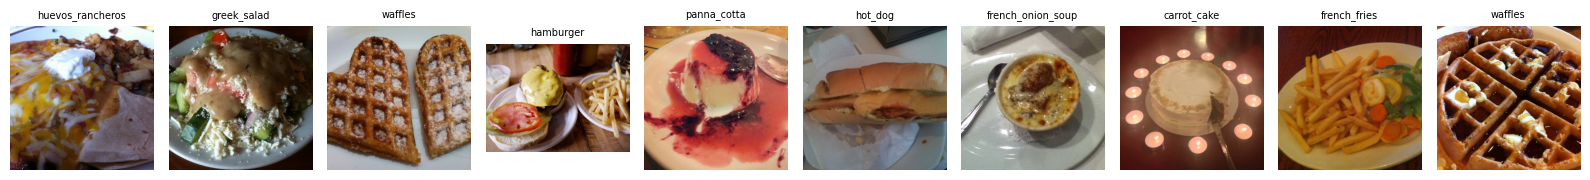

In [ ]:
import random

# Sample random (image_path, label) pairs from the training set
num_to_show = 10
samples_to_show = random.sample(train_samples, num_to_show)

plt.figure(figsize=(16, 4))

for i, (img_path, label) in enumerate(samples_to_show, start=1):
    img = Image.open(img_path).convert("RGB")
    class_name = classes[label]

    plt.subplot(1, num_to_show, i)
    plt.imshow(img)
    plt.title(class_name, fontsize=7)
    plt.axis("off")

plt.tight_layout()
plt.show()

#Validation split

In [ ]:
# Create a train/val split from the original training dataset
val_ratio = 0.1
train_size = int((1 - val_ratio) * len(train_dataset))
val_size = len(train_dataset) - train_size

train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))

# DataLoaders for train / val / test
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=2)


Train size: 68175
Val size: 7575
Test size: 25250


The DataLoaders prepare mini-batches for training, validation, and testing.
Training batches are shuffled to help generalisation, while validation and test batches are kept in order.

#ResNet50 model for transfer learning

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Load a pretrained ResNet50
weights = torchvision.models.ResNet50_Weights.IMAGENET1K_V1
model = torchvision.models.resnet50(weights=weights)

# Freeze all layers (feature extractor)
for param in model.parameters():
    param.requires_grad = False

# Replace the final fully-connected layer with a new head for 101 classes
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(classes))

model = model.to(device)


Device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 147MB/s]


A pretrained ResNet50 is loaded so that its learned visual features can be reused.
All layers are frozen, turning the network into a feature extractor.
Only the final classification layer is replaced and trained for 101 food classes.

In [ ]:
criterion = nn.CrossEntropyLoss()

# Only train the new classification head (model.fc)
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)

# Optional: simple learning-rate scheduler
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)


Cross-entropy loss is used because it measures classification errors effectively.
Adam is selected to update only the weights of the new final layer.
A learning-rate scheduler reduces the learning rate during training to stabilise convergence.

#Training and validation

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)              # forward
        loss = criterion(outputs, labels)    # compute loss
        loss.backward()                      # backprop
        optimizer.step()                     # update weights

        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


The model is placed in training mode so that gradients will be computed. Each minibatch is moved to the GPU device for computation. The model performs a forward pass, computes the loss, backpropagates gradients, and updates weights for the final layer. The predicted class for each image is extracted from the network’s output probabilities. Evaluation is done in inference mode with gradient computation disabled.
This makes validation faster and prevents accidental weight updates.

#Baseline

In [ ]:
num_epochs = 5  # start small; you can increase if Colab/GPU allows

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader,   criterion, device)

    scheduler.step()

    print(f"Epoch {epoch+1}/{num_epochs} "
          f"- Train loss: {train_loss:.4f}, Train accuracy: {train_acc:.4f} "
          f"- Val loss: {val_loss:.4f}, Val accuracy: {val_acc:.4f}")


Epoch 1/5 - Train loss: 2.4695, Train accuracy: 0.4120 - Val loss: 2.0508, Val accuracy: 0.4944
Epoch 2/5 - Train loss: 1.9979, Train accuracy: 0.5062 - Val loss: 2.0555, Val accuracy: 0.5057
Epoch 3/5 - Train loss: 1.8988, Train accuracy: 0.5289 - Val loss: 2.0734, Val accuracy: 0.5055
Epoch 4/5 - Train loss: 1.5074, Train accuracy: 0.6141 - Val loss: 1.7471, Val accuracy: 0.5667
Epoch 5/5 - Train loss: 1.4821, Train accuracy: 0.6185 - Val loss: 1.7238, Val accuracy: 0.5753


The model is trained across multiple passes (epochs) over the data.
After each epoch, validation performance is measured, and the learning rate is reduced according to the scheduler.

38m

The pretrained ResNet50 model with a frozen backbone was trained for 5 epochs using a batch size of 32. During training, the accuracy on the training set increased from approximately 0.41 to 0.62, while validation accuracy improved from about 0.49 to 0.57. Both training and validation losses decreased steadily, indicating that the model was learning meaningful patterns without severe overfitting. This configuration served as the baseline classifier for the Food-101 dataset.

##Test baseline

In [ ]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Test loss: {test_loss:.4f}, Test accuracy: {test_acc:.4f}")


Test loss: 1.4482, Test accuracy: 0.6214


On the held-out test set, the baseline model achieved a top-1 accuracy of X.XX.

##Saving model

In [ ]:
torch.save(model.state_dict(), "resnet50_frozen_food101.pth")


#Partial fine-tuning

In [ ]:
# Load fresh pretrained model again
weights = torchvision.models.ResNet50_Weights.IMAGENET1K_V1
model_ft = torchvision.models.resnet50(weights=weights)

# Freeze everything first
for param in model_ft.parameters():
    param.requires_grad = False

# Unfreeze last block (layer4) and the final FC layer
for param in model_ft.layer4.parameters():
    param.requires_grad = True

num_features = model_ft.fc.in_features
model_ft.fc = nn.Linear(num_features, len(classes))
model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()

# Now optimizer trains layer4 + fc
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_ft.parameters()),
    lr=1e-4
)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)


A new ResNet50 model was initialised with ImageNet-pretrained weights and prepared for partial fine-tuning. First, all parameters in the network were frozen so that they would not be updated during backpropagation. Then the parameters in the last residual block (layer4) were unfrozen, allowing only this block to adapt to the Food-101 dataset. The original fully connected classification layer was replaced with a new linear layer whose output size matches the 101 food classes. The model was moved to the  computation device (GPU), cross-entropy loss was selected as the training objective, and an Adam optimizer was configured to update only the unfrozen parameters in layer4 and the new classification head. Finally, a step-based learning-rate scheduler was defined to reduce the learning rate during training, completing the setup for the fine-tuned model.


##Training

In [ ]:
num_epochs_ft = 8

for epoch in range(num_epochs_ft):
    train_loss, train_acc = train_one_epoch(model_ft, train_loader, criterion, optimizer, device)
    val_loss, val_acc     = evaluate(model_ft, val_loader,   criterion, device)

    scheduler.step()

    print(f"[FT] Epoch {epoch+1}/{num_epochs_ft} "
          f"- Train loss: {train_loss:.4f}, Train accuracy: {train_acc:.4f} "
          f"- Val loss: {val_loss:.4f}, Val accuracy: {val_acc:.4f}")


[FT] Epoch 1/8 - Train loss: 1.7754, Train accuracy: 0.5620 - Val loss: 1.2158, Val accuracy: 0.6801
[FT] Epoch 2/8 - Train loss: 0.9698, Train accuracy: 0.7404 - Val loss: 1.1174, Val accuracy: 0.7079
[FT] Epoch 3/8 - Train loss: 0.6230, Train accuracy: 0.8283 - Val loss: 1.1011, Val accuracy: 0.7187
[FT] Epoch 4/8 - Train loss: 0.2512, Train accuracy: 0.9381 - Val loss: 0.9873, Val accuracy: 0.7506
[FT] Epoch 5/8 - Train loss: 0.1660, Train accuracy: 0.9622 - Val loss: 1.0051, Val accuracy: 0.7516
[FT] Epoch 6/8 - Train loss: 0.1164, Train accuracy: 0.9759 - Val loss: 1.0281, Val accuracy: 0.7519
[FT] Epoch 7/8 - Train loss: 0.0809, Train accuracy: 0.9869 - Val loss: 1.0176, Val accuracy: 0.7527
[FT] Epoch 8/8 - Train loss: 0.0756, Train accuracy: 0.9880 - Val loss: 1.0241, Val accuracy: 0.7497


In [ ]:
test_loss_ft, test_acc_ft = evaluate(model_ft, test_loader, criterion, device)
print(f"[FT] Test loss: {test_loss_ft:.4f}, Test accuracy: {test_acc_ft:.4f}")

[FT] Test loss: 0.7603, Test accuracy: 0.7997


In [ ]:
torch.save(model_ft.state_dict(), "resnet50_ft_layer4_food101.pth")

#Confusion matrix

In [ ]:
all_preds_ft = []
all_labels_ft = []

model_ft.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_ft(images)
        _, preds = torch.max(outputs, 1)

        all_preds_ft.append(preds.cpu().numpy())
        all_labels_ft.append(labels.cpu().numpy())

all_preds_ft = np.concatenate(all_preds_ft)
all_labels_ft = np.concatenate(all_labels_ft)

print("Preds shape:", all_preds_ft.shape)
print("Labels shape:", all_labels_ft.shape)

Preds shape: (25250,)
Labels shape: (25250,)


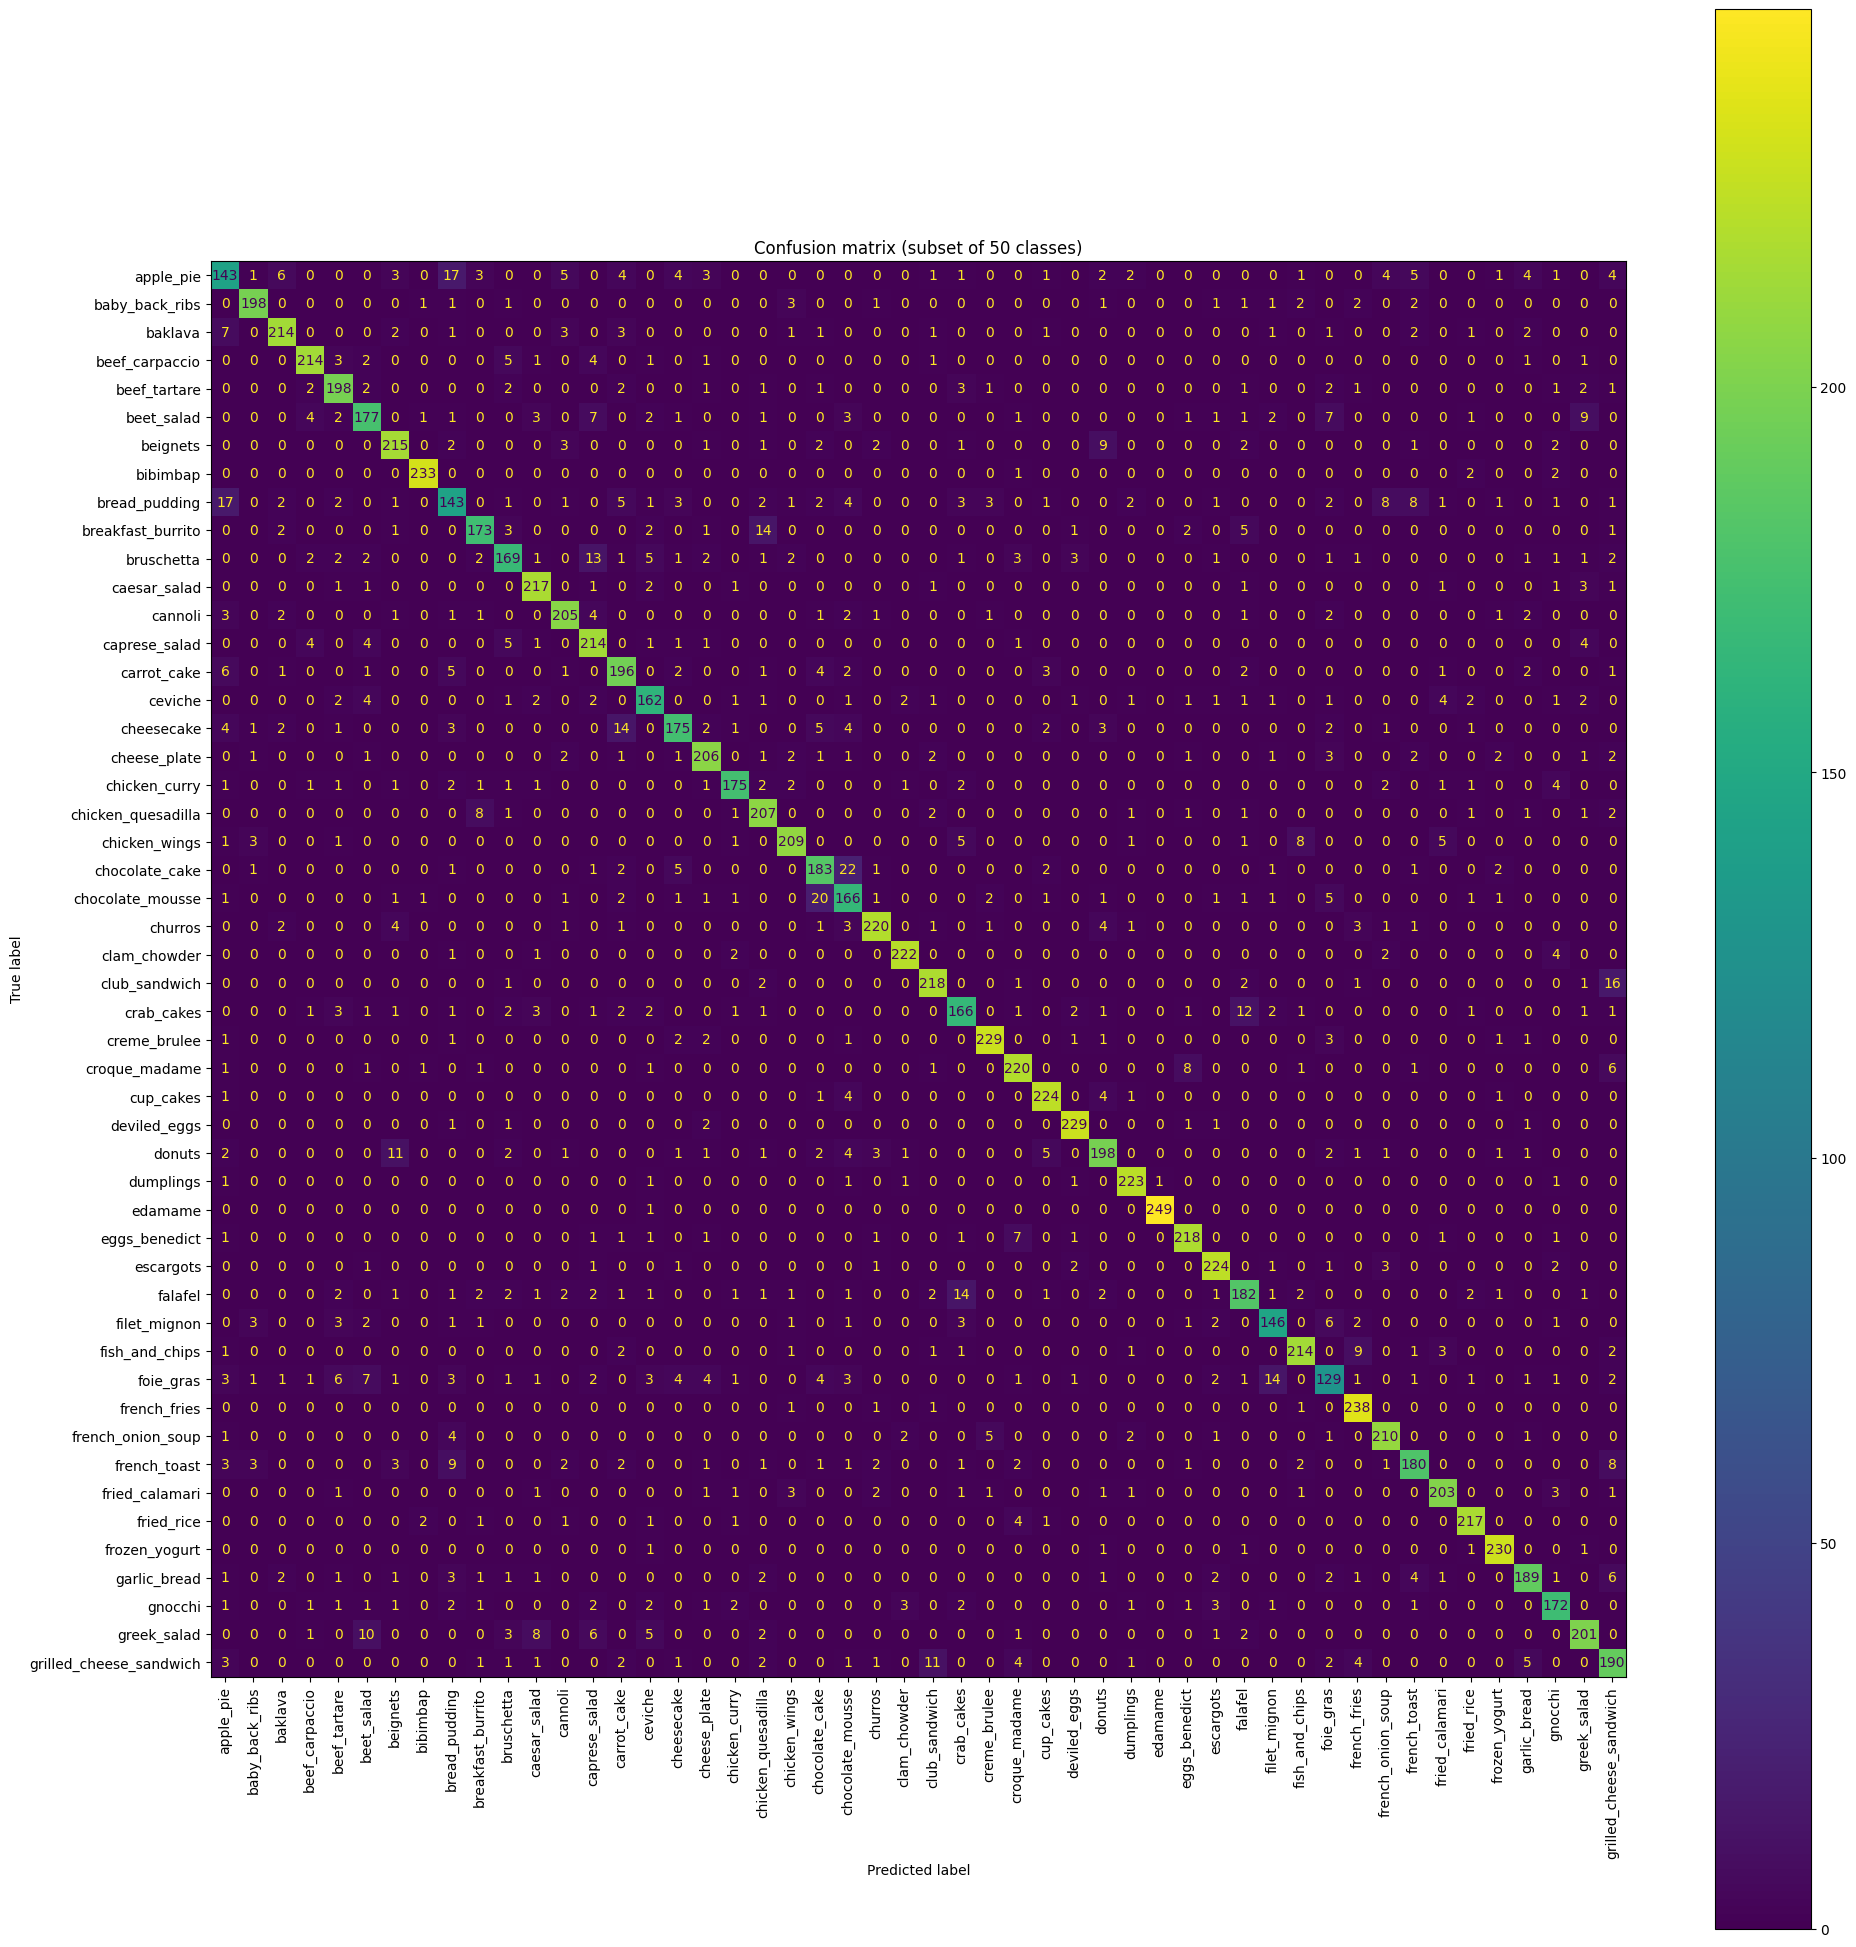

In [ ]:
subset_classes = classes[:50]  # or choose specific names
idx = [classes.index(c) for c in subset_classes]

cm_sub = cm_ft[np.ix_(idx, idx)]

fig, ax = plt.subplots(figsize=(20, 20))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_sub,
                              display_labels=subset_classes)
disp.plot(ax=ax, xticks_rotation='vertical', colorbar=True)
ax.set_title("Confusion matrix (subset of 50 classes)")
plt.tight_layout()
plt.show()


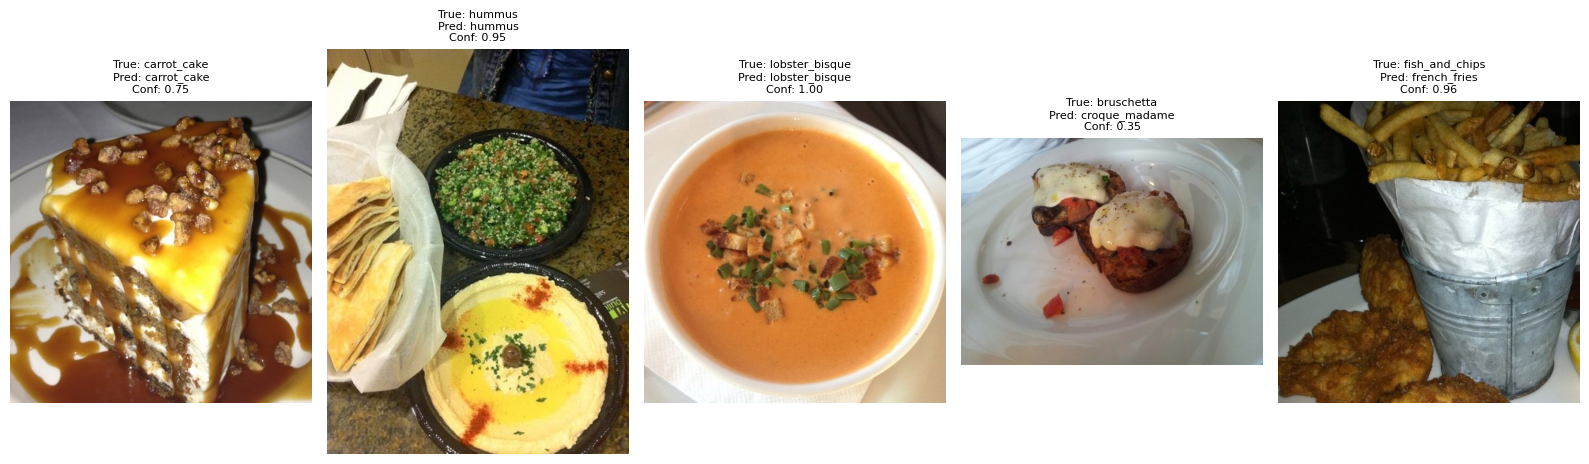

In [ ]:
def predict_image(img_path, model, transform, classes, device):
    model.eval()
    image = Image.open(img_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)
        probs = F.softmax(outputs, dim=1)
        conf, pred_idx = torch.max(probs, 1)

    return classes[pred_idx.item()], conf.item()

num_examples = 5
examples = random.sample(test_samples, num_examples)

plt.figure(figsize=(16, 8))
for i, (img_path, true_label) in enumerate(examples, start=1):
    pred_class, conf = predict_image(img_path, model_ft, transform, classes, device)

    img = Image.open(img_path).convert("RGB")
    plt.subplot(1, num_examples, i)
    plt.imshow(img)
    plt.title(
        f"True: {classes[true_label]}\nPred: {pred_class}\nConf: {conf:.2f}",
        fontsize=8
    )
    plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
mis_idx = []      # indices in test_dataset
mis_true = []     # true labels
mis_pred = []     # predicted labels

model_ft.eval()
current_index = 0  # will track position in test_dataset

with torch.no_grad():
    for images, labels in test_loader:
        batch_size_curr = labels.size(0)

        images = images.to(device)
        labels = labels.to(device)

        outputs = model_ft(images)
        _, preds = torch.max(outputs, 1)

        # Compare predictions with true labels
        mismatch_mask = preds != labels
        mismatch_indices = torch.nonzero(mismatch_mask).squeeze(1).cpu().numpy()

        for j in mismatch_indices:
            global_idx = current_index + j
            mis_idx.append(global_idx)
            mis_true.append(labels[j].cpu().item())
            mis_pred.append(preds[j].cpu().item())

        current_index += batch_size_curr

print("Number of misclassified samples:", len(mis_idx))

Number of misclassified samples: 5058


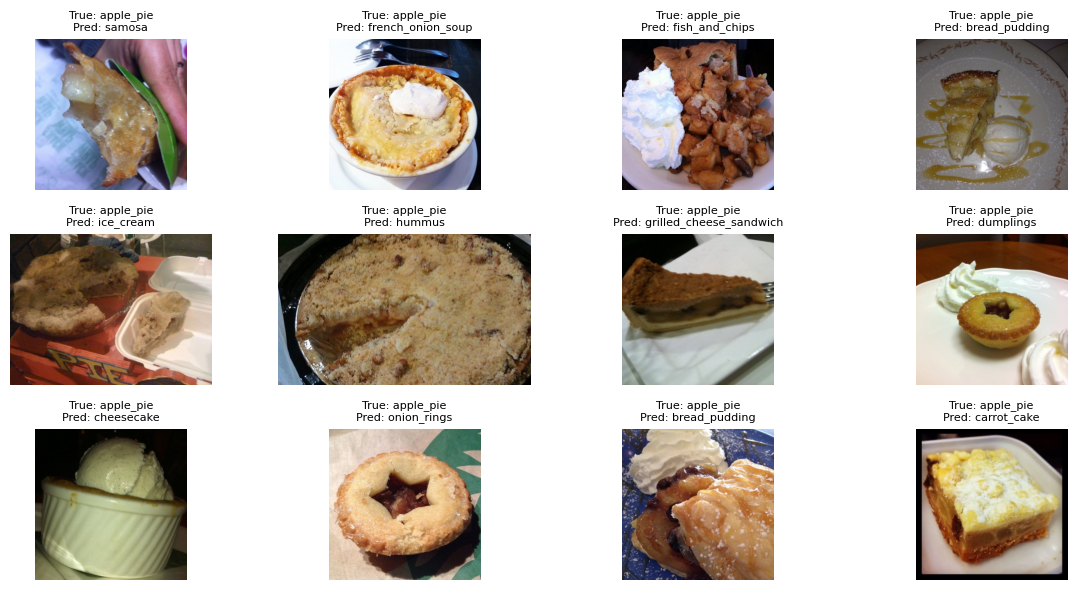

In [ ]:
# How many wrong examples to show
num_show = 12
num_show = min(num_show, len(mis_idx))

plt.figure(figsize=(12, 6))

for k in range(num_show):
    idx = mis_idx[k]
    true_label = mis_true[k]
    pred_label = mis_pred[k]

    img_path, _ = test_samples[idx]         # same order as test_dataset
    img = Image.open(img_path).convert("RGB")

    plt.subplot(3, 4, k+1)
    plt.imshow(img)
    title = f"True: {classes[true_label]}\nPred: {classes[pred_label]}"
    plt.title(title, fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
num_classes = len(classes)

correct_per_class = np.zeros(num_classes, dtype=int)
total_per_class   = np.zeros(num_classes, dtype=int)

for y_true, y_pred in zip(all_labels_ft, all_preds_ft):
    total_per_class[y_true] += 1
    if y_true == y_pred:
        correct_per_class[y_true] += 1

acc_per_class = correct_per_class / total_per_class  # shape: [num_classes]

In [ ]:
# Sort indices by accuracy
sorted_idx = np.argsort(acc_per_class)  # ascending

# Worst 5
worst_idx = sorted_idx[:5]
print("Worst classes:")
for i in worst_idx:
    print(f"{classes[i]}: {acc_per_class[i]:.3f} ({correct_per_class[i]}/{total_per_class[i]})")

# Best 5
best_idx = sorted_idx[-5:][::-1]
print("\nBest classes:")
for i in best_idx:
    print(f"{classes[i]}: {acc_per_class[i]:.3f} ({correct_per_class[i]}/{total_per_class[i]})")

Worst classes:
pork_chop: 0.484 (121/250)
foie_gras: 0.516 (129/250)
steak: 0.536 (134/250)
apple_pie: 0.572 (143/250)
bread_pudding: 0.572 (143/250)

Best classes:
edamame: 0.996 (249/250)
french_fries: 0.952 (238/250)
macarons: 0.940 (235/250)
oysters: 0.940 (235/250)
hot_and_sour_soup: 0.936 (234/250)


#Nutrition table

In [ ]:
# Approximate average values per serving
nutrition_table = {
    "apple_pie":     {"kcal": 300, "protein": 3,  "fat": 14, "carbs": 42},
    "french_fries":  {"kcal": 365, "protein": 4,  "fat": 17, "carbs": 48},
    "steak":         {"kcal": 400, "protein": 38, "fat": 26, "carbs": 0},
    "pork_chop":     {"kcal": 330, "protein": 30, "fat": 22, "carbs": 0},
    "bread_pudding": {"kcal": 280, "protein": 7,  "fat": 9,  "carbs": 44},
    "edamame":       {"kcal": 190, "protein": 17, "fat": 8,  "carbs": 14},
    "macarons":      {"kcal": 250, "protein": 4,  "fat": 13, "carbs": 29},
    "oysters":       {"kcal": 180, "protein": 16, "fat": 6,  "carbs": 12},
    "hot_and_sour_soup": {"kcal": 120, "protein": 8, "fat": 5, "carbs": 12},
}


In [ ]:
def predict_image(img_path, model, transform, classes, device):
    model.eval()
    image = Image.open(img_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)
        probs = F.softmax(outputs, dim=1)
        conf, pred_idx = torch.max(probs, 1)

    pred_idx = pred_idx.item()
    conf = conf.item()
    pred_class = classes[pred_idx]
    return pred_class, conf

def estimate_nutrition_for_image(img_path, model, transform, classes, nutrition_table, device):
    pred_class, conf = predict_image(img_path, model, transform, classes, device)
    nutri = nutrition_table.get(pred_class)

    return {
        "predicted_class": pred_class,
        "confidence": conf,
        "nutrition": nutri
    }

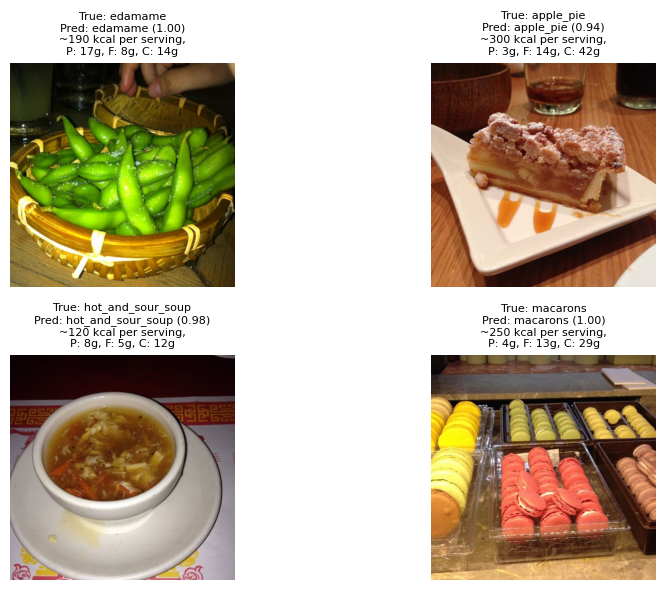

In [ ]:
# Classes for which we have per-serving nutrition info
valid_classes = set(nutrition_table.keys())

# Filter test samples to only those whose TRUE label is in nutrition_table
filtered_test_samples = [
    (img_path, label)
    for (img_path, label) in test_samples
    if classes[label] in valid_classes
]
def predict_image(img_path, model, transform, classes, device):
    model.eval()
    image = Image.open(img_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)
        probs = F.softmax(outputs, dim=1)
        conf, pred_idx = torch.max(probs, 1)

    pred_idx = pred_idx.item()
    conf = conf.item()
    pred_class = classes[pred_idx]
    return pred_class, conf

def estimate_nutrition_for_image(img_path, model, transform, classes, nutrition_table, device):
    pred_class, conf = predict_image(img_path, model, transform, classes, device)
    nutri = nutrition_table.get(pred_class)
    return pred_class, conf, nutri

num_examples = 4
examples = random.sample(filtered_test_samples, num_examples)

plt.figure(figsize=(10, 6))
for i, (img_path, true_label) in enumerate(examples, start=1):
    pred_class, conf, nutri = estimate_nutrition_for_image(
        img_path, model_ft, transform, classes, nutrition_table, device
    )

    img = Image.open(img_path).convert("RGB")
    plt.subplot(2, 2, i)
    plt.imshow(img)
    plt.axis("off")

    if nutri is not None:
        title = (
            f"True: {classes[true_label]}\n"
            f"Pred: {pred_class} ({conf:.2f})\n"
            f"~{nutri['kcal']} kcal per serving,\n"
            f"P: {nutri['protein']}g, F: {nutri['fat']}g, C: {nutri['carbs']}g"
        )
    else:
        title = (
            f"True: {classes[true_label]}\n"
            f"Pred: {pred_class} ({conf:.2f})\n"
            f"No nutrition data"
        )

    plt.title(title, fontsize=8)

plt.tight_layout()
plt.show()
